In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [11]:
fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046,             # Effective number of relativistic species
    'sigma8_0':  0.8123578481137994
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,

    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,

    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,
    
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,

    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0

}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])
nell = len(ell_theory)
ell_theory_diff = ell_theory[1:]-ell_theory[:-1]


# Linear bias cuts

First we want to know linear-scale cuts in GGL and GC. One way of computing the correspondence of $k_{\rm max} = [0.1, 0.3] ~h/{\rm Mpc}$ to $\ell_{\rm max}$ using the mod-redshift which corresponds to the maximum of the lensing kernel:

$$
\ell_{\rm max} = k_{\rm max} \frac{\chi(z_{\rm mod})}{1+z_{\rm mod}} \, .
$$

See Sylvain's paper for a different and **less conservative** approach with $\alpha=0.95$ and $k_{>\alpha}(\ell_{\rm max})=k_{\rm max}$:

$$
\int_{-\inf}^{\ln{k_{>\alpha}(\ell)}} \mathrm{d} \ln{k} \frac{\mathrm{d}C_\ell}{\mathrm{d} \ln{k}} = \alpha C_\ell \, .
$$

In [12]:
# Compatible with previous versions of euclidlib
#z_nz_pos, nz_pos = el.photo.redshift_distributions('TR1_data/TR1_v1_Nz_GC_C2020_sel_pv.fits')
#z_nz_she, nz_she = el.photo.redshift_distributions('TR1_data/TR1_v1_Nz_WL_C2020_sel_pv.fits')
z_nz_pos, nz_pos = el.phz.redshift_distributions('TR1_data/TR1_v1_Nz_GC_C2020_sel_pv.fits')
z_nz_she, nz_she = el.phz.redshift_distributions('TR1_data/TR1_v1_Nz_WL_C2020_sel_pv.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_pos, z_nz_pos, myz)
my_dndz_she_norm = normalize_and_resample(nz_she, z_nz_she, myz)


In [13]:
# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
perturbations = HMemuNonLinearPerturbations(
    background, 
    HMemuLinearPerturbations(background, myz), 
    myz, 
    log10TAGN=cosmo_params['log10TAGN']
)

perturbations_nobaryons = HMemuNonLinearPerturbations(
    background, 
    HMemuLinearPerturbations(background, myz), 
    myz, 
    log10TAGN=None
)


In [ ]:
# Tracer definitions (easy to swap dndz, bias model, etc.)
tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    ia_model='NLA',
    nuisance_params=nuisance_params
)


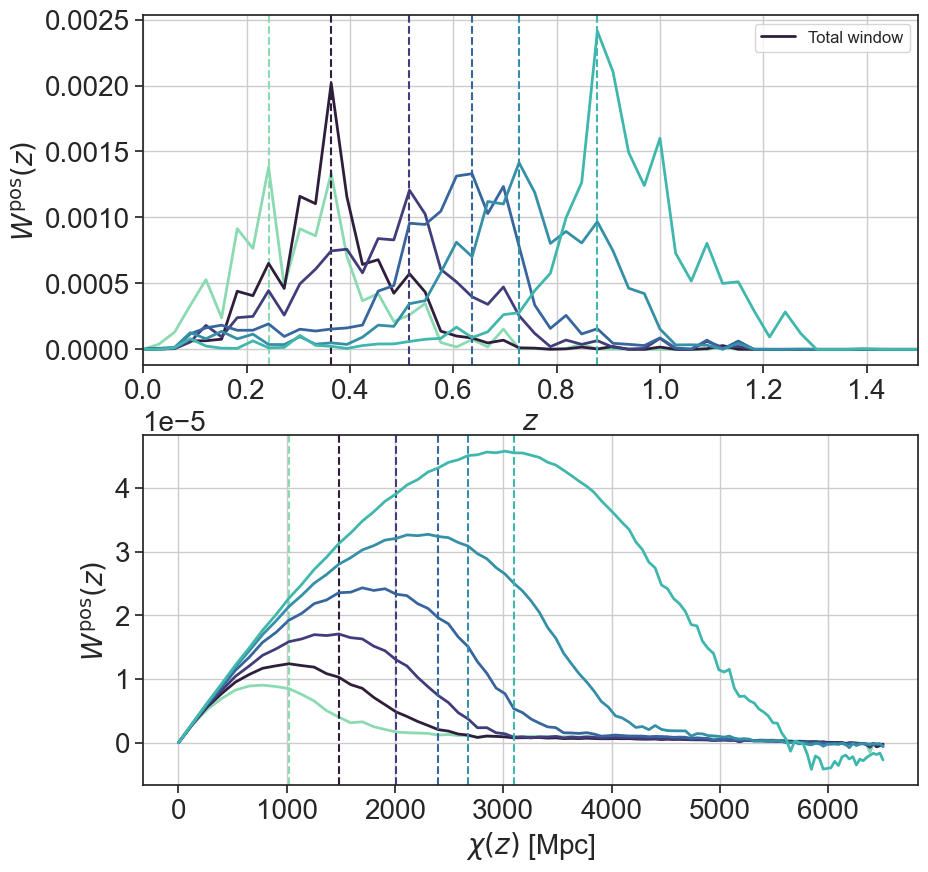

In [15]:
z_mod = []
comdis_mod = []
colors = sns.color_palette("mako", len(nz_pos))
# Create the figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
for i in range(6):
    # Plot the window
    axs[0].plot(perturbations.z, 
             tracer_pos.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    ind = np.argmax(tracer_pos.get_window(perturbations.z)[i, :])
    zmod = perturbations.z[ind]
    z_mod.append(zmod)
    axs[0].axvline(x=zmod, color=colors[i-1], linewidth=1.5, linestyle='--')

    axs[1].plot(perturbations.background.comoving_distance((perturbations.z)), 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    comdismod = perturbations.background.comoving_distance((perturbations.z))[ind]
    comdis_mod.append(comdismod)
    axs[1].axvline(x=comdismod, color=colors[i-1], linewidth=1.5, linestyle='--')

    
# Label the axes
axs[0].set_xlabel(r'$z$');axs[1].set_xlabel(r'$\chi(z)$ [Mpc]')
axs[0].set_ylabel(r'$W^{\rm pos}(z)$');axs[1].set_ylabel(r'$W^{\rm pos}(z)$')

# Add the legend and grid
axs[0].legend(fontsize=12, loc='upper right')
axs[0].grid(True);axs[1].grid(True)
axs[0].set_xlim(0, 1.5)
# Show the plot
plt.show()


In [16]:
def from_kmax_to_lmax(kmax):
    print(f'for kmax = {kmax:.2f} 1/Mpc')
    lmax_list = [kmax * comdis / (1 + z) for comdis, z in zip(comdis_mod, z_mod)]
    for i, lmax in enumerate(lmax_list, start=1):
        print(f'bin {i} - lmax = {lmax:.2f}')
    return lmax_list

lmax_0p1 = from_kmax_to_lmax(perturbations.background.h * 0.1)
lmax_0p3 = from_kmax_to_lmax(perturbations.background.h * 0.3)


for kmax = 0.07 1/Mpc
bin 1 - lmax = 55.00
bin 2 - lmax = 72.72
bin 3 - lmax = 88.88
bin 4 - lmax = 98.27
bin 5 - lmax = 103.72
bin 6 - lmax = 110.47
for kmax = 0.20 1/Mpc
bin 1 - lmax = 164.99
bin 2 - lmax = 218.15
bin 3 - lmax = 266.65
bin 4 - lmax = 294.80
bin 5 - lmax = 311.16
bin 6 - lmax = 331.41


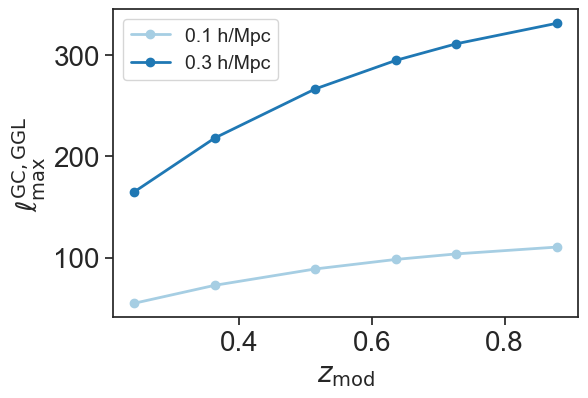

In [17]:
# Create the figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(z_mod, lmax_0p1, label='0.1 h/Mpc', linewidth=2, fmt='-o')
ax.errorbar(z_mod, lmax_0p3, label='0.3 h/Mpc', linewidth=2, fmt='-o')
ax.legend()
ax.set_xlabel(r'$z_{\rm mod}$')
ax.set_ylabel(r'$\ell_{\rm max}^{\rm GC,GGL}$')
plt.show()


# Initial guess for scale-cuts in SHEAR based on $\chi^2$

In the example here we have 

* contamination = hmcode with baryonic feedback $\log_{10} T_{\rm AGN} = 7.75$ 
* baseline = hmcode without any baryonic feedback

In [ ]:
def compute_cells(perturbations):
    # Tracer definitions (easy to swap dndz, bias model, etc.)
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=my_dndz_pos_norm,
        z=myz,
        galaxy_bias_model='poly',
        nuisance_params=fiducial_nuisance
    )
    
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=my_dndz_she_norm,
        z=myz,
        ia_model='NLA',
        nuisance_params=fiducial_nuisance
    )
    # 🎯 Compute all the 2-point angular power spectra in one go!
    cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
    return cls_sheshe, cls_posshe, cls_pospos


In [19]:
cells_wl = {}
cells_ggl = {}
cells_gc = {}
labels = ['contaminated', 'baseline']
labels_names = ['contaminated (baryons)', 'baseline (no baryons)']

In [20]:
nonlinear_perturbations_contaminated = perturbations
nonlinear_perturbations_baseline = perturbations_nobaryons

for label in labels:
    perturbations = eval(f'nonlinear_perturbations_{label}')
    cells_wl[label], cells_ggl[label], cells_gc[label] = compute_cells(perturbations)

In [21]:
full_cov=np.load('TR1_data/covariance_Gauss_Euclid_DR1_brighter_cut_1589_TR1_2D.npz')['Gauss']
# Extract weak lensing covariance submatrix
# Shape: (n_tomographic_pairs * n_ell_bins, n_tomographic_pairs * n_ell_bins)
# For 6 bins: (21+21)*32 = 1344 elements (EE + BB correlations)
n_she_bins = len(nz_she)
shear_pairs = int(n_she_bins*(n_she_bins+1)/2)

n_pos_bins = len(nz_pos)
pos_pairs = int(n_pos_bins*(n_pos_bins+1)/2)

cov_WL = full_cov[:shear_pairs*nell, :shear_pairs*nell]
print('WL cov: ', cov_WL.shape)

cov_GC = full_cov[-pos_pairs*nell:, -pos_pairs*nell:]
print('GC cov: ', cov_GC.shape)

cov_GGL = full_cov[shear_pairs*nell:-pos_pairs*nell, shear_pairs*nell:-pos_pairs*nell]
print('GGL cov: ', cov_GGL.shape)

print('full cov: ', full_cov.shape)

WL cov:  (672, 672)
GC cov:  (672, 672)
GGL cov:  (1152, 1152)
full cov:  (2496, 2496)


In [22]:
errors_wl = np.sqrt(np.diag(cov_WL))
pairs_wl = []
for i in range(n_she_bins):
    for j in range(i+1):
        pairs_wl.append((i, j))
WL_keys = [
            ("SHE", "SHE", i, j)
            for i in range(1, n_she_bins + 1)
            for j in range(i, n_she_bins + 1)
        ]

# Cut with $\chi^2_{\rm max}$ threshold in each individual shear bin

Here we set a criterium to systematically remove points starting with $\ell_{\rm max}^{\rm start}$ in steps of $\Delta \ell = 1$ until in each bin $\chi^2 < \chi^2_{\rm max}$.

bin 11: chi2=0.6232324831355389 with ell_max_start=3000; chi2_new=0.6232324831355389 ell_max=2755.10835283
bin 21: chi2=1.77449404338559 with ell_max_start=3000; chi2_new=1.3555684280694775 ell_max=1614.01871364
bin 22: chi2=3.0040159485093065 with ell_max_start=3000; chi2_new=1.4910202147160065 ell_max=1130.02613377
bin 31: chi2=2.199000554754751 with ell_max_start=3000; chi2_new=1.3328938603782856 ell_max=1350.51224608
bin 32: chi2=4.001422670143661 with ell_max_start=3000; chi2_new=1.2861620537230274 ell_max=945.53682628
bin 33: chi2=5.8197972372367435 with ell_max_start=3000; chi2_new=1.0873552421127992 ell_max=791.16744571
bin 41: chi2=1.5374160657220994 with ell_max_start=3000; chi2_new=1.412530876748468 ell_max=2305.30633773
bin 42: chi2=6.003142550499435 with ell_max_start=3000; chi2_new=1.4800847643220718 ell_max=791.16744571
bin 43: chi2=10.038203129054878 with ell_max_start=3000; chi2_new=1.3966136162886518 ell_max=662.00057974
bin 44: chi2=16.23335253987034 with ell_max_sta

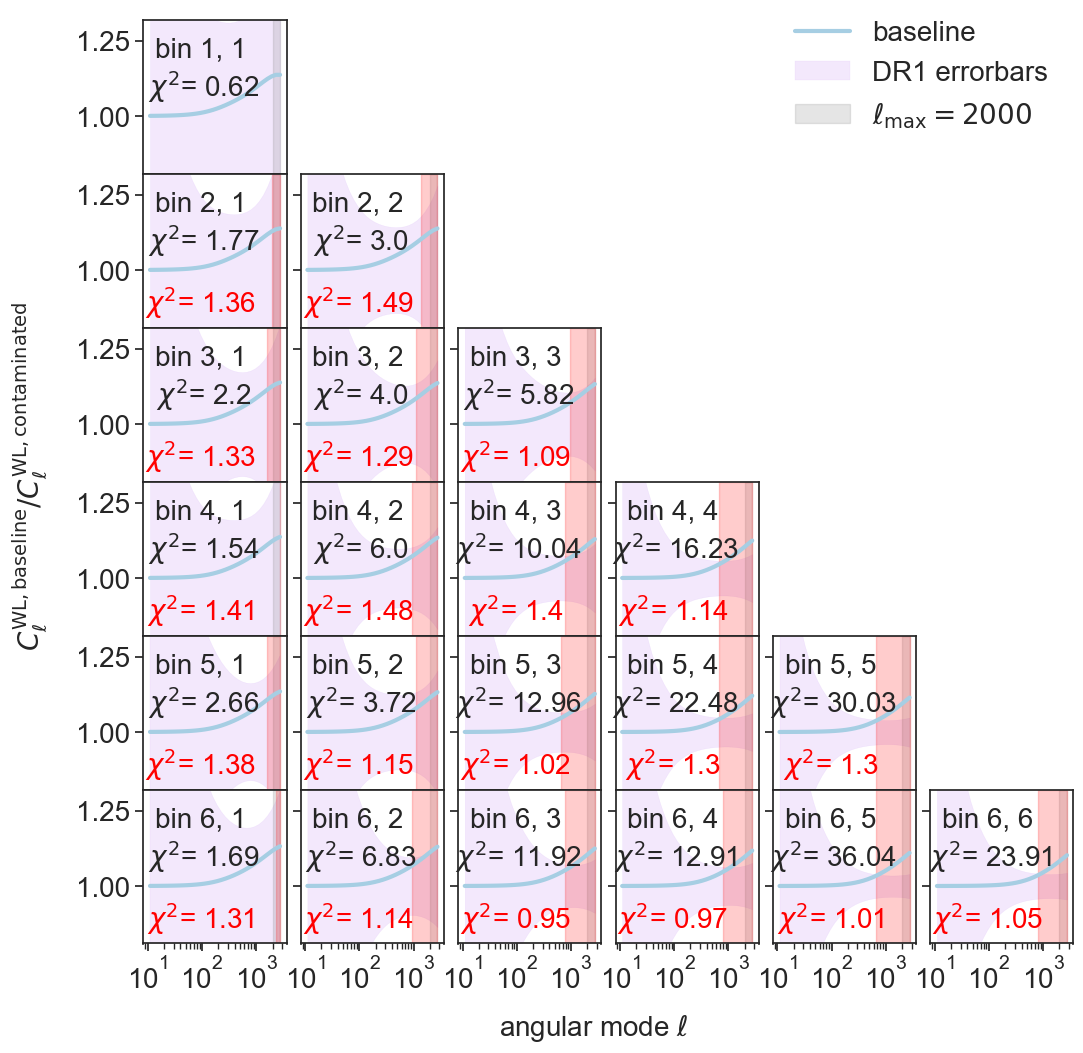

In [23]:
ell_max_start = 3000
chi2_max_ij = 1.5
fig, ax = plt.subplots(n_she_bins, n_she_bins, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(n_she_bins):
    for j in range(n_she_bins):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            y = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            ax[i,j].semilogx(ell_theory,  y)

            diff = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            mask = ell_theory<ell_max_start
            chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
            n = 1
            chi2_new = chi2
            mask_new = ell_theory < ell_max_start
            if chi2>chi2_max_ij:
                while chi2_new>chi2_max_ij:
                    mask_new = ell_theory < (ell_max_start - n)
                    chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                    n +=1
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .5, 'bin %s, %s\n $\\chi^2$= %s'%(str(i+1),(j+1), round(chi2, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=2000, xmax=ell_theory[-1], color='grey', alpha=0.2)
            ax[i, j].set_ylim(0.81, 1.32)
            print(f"bin {i+1}{j+1}: chi2={chi2} with ell_max_start={ell_max_start}; chi2_new={chi2_new} ell_max={ell_theory[mask_new][-1]}")
       
            if chi2_new != chi2:
                ax[i,j].text(.4, .1, '$\\chi^2$= %s'%(round(chi2_new, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes, color='red')
                ax[i, j].axvspan(xmin=ell_max_start - n, xmax=ell_theory[-1], color='red', alpha=0.2)
                
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL, baseline}_{\ell}/C^{\rm WL, contaminated}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['baseline', 'DR1 errorbars', '$\\ell_{\\rm max}=2000$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

# Cut with $\chi^2_{\rm max}$ threshold for all shear bins

Here we set a criterium to systematically remove points starting with highest $\chi^2$ until in total $\chi^2 < \chi^2_{\rm max}$. In contrast to the previous approach, here we take the off-diagonal components of the covariance into account.

In [24]:
data = np.array(
            [cells_wl['contaminated'][key][0, 0] for key in WL_keys]
        ).flatten()
theory = np.array(
            [cells_wl['baseline'][key][0, 0] for key in WL_keys]
        ).flatten()
C = cov_WL

diff = theory - data
invC = np.linalg.inv(C)

chi2 = diff @ invC @ diff
chi2

np.float64(112.33361037692966)

In [25]:
# Per-point chi^2 contribution for each tomographic bin pair.
# Using the full-cov decomposition:  chi2 = sum_i diff_i * (invC @ diff)_i
v = invC @ diff
chi2_per_point = diff * v  # shape: (n_pairs * nell,)
assert np.isclose(chi2_per_point.sum(), chi2), "per-point sum must match total chi2"
chi2_contribution = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    start = p * nell
    end = (p + 1) * nell
    chi2_contribution[f"bin {i}{j}"] = {
        "ell":  ell_theory.tolist(),
        "chi2": chi2_per_point[start:end].tolist(),
    }
print(f"Total chi2                       = {chi2:.4f}")
print(f"Sum of per-point contributions   = "
      f"{sum(sum(b['chi2']) for b in chi2_contribution.values()):.4f}")
for bin_label, vals in chi2_contribution.items():
    print(f"  {bin_label}: chi2 = {sum(vals['chi2']):.4f}")


Total chi2                       = 112.3336
Sum of per-point contributions   = 112.3336
  bin 11: chi2 = 0.3448
  bin 12: chi2 = 0.9466
  bin 13: chi2 = 1.1929
  bin 14: chi2 = 1.3492
  bin 15: chi2 = 1.4181
  bin 16: chi2 = 1.2191
  bin 22: chi2 = 0.7485
  bin 23: chi2 = 2.1536
  bin 24: chi2 = 2.7180
  bin 25: chi2 = 3.0876
  bin 26: chi2 = 2.8542
  bin 33: chi2 = 1.7779
  bin 34: chi2 = 5.0710
  bin 35: chi2 = 6.3067
  bin 36: chi2 = 6.3232
  bin 44: chi2 = 4.1053
  bin 45: chi2 = 11.3893
  bin 46: chi2 = 12.5216
  bin 55: chi2 = 8.9718
  bin 56: chi2 = 22.1554
  bin 66: chi2 = 15.6787


In [26]:
chi2_max = 1.5

# Tag every global data-vector index with (bin_label, ell, bin_idx, ell_idx).
# bin_idx is the position of the (i, j) pair inside WL_keys; ell_idx is the
# index into ell_theory.  This lets us enforce the "remove only from the
# high-ell end of each bin" constraint, so kept ells stay contiguous from
# l_min upward in every bin.
point_tags = []
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    bin_label = f"bin {i}{j}"
    for k, ell_val in enumerate(ell_theory):
        point_tags.append((bin_label, float(ell_val), p, k))

keep_mask = np.ones(len(diff), dtype=bool)

def chi2_with_mask(mask):
    """Recompute chi2 and per-point contributions on the *kept* subset by
    inverting the corresponding sub-covariance."""
    d_sub    = diff[mask]
    C_sub    = C[np.ix_(mask, mask)]
    invC_sub = np.linalg.inv(C_sub)
    v_sub    = invC_sub @ d_sub
    return d_sub @ v_sub, d_sub * v_sub

chi2_cur, per_point_cur = chi2_with_mask(keep_mask)
print(f"Initial chi2 = {chi2_cur:.4f}   (n_points = {keep_mask.sum()})\n")

# For every bin (position p in WL_keys), track its highest currently kept
# ell-index.  Only that point is eligible for removal at any step.
highest_kept = {p: nell - 1 for p in range(len(WL_keys))}

removed = []
max_iter = len(diff)  # safety cap

while chi2_cur > chi2_max and len(removed) < max_iter:
    # Map per-point contributions (over kept subarray) back to global indices.
    active_global  = np.where(keep_mask)[0]
    contrib_global = np.full(len(diff), -np.inf)
    contrib_global[active_global] = per_point_cur

    # Candidates: for each bin still having points, the contribution at its
    # current highest-ell index.
    candidates = []
    for p, k_top in highest_kept.items():
        if k_top is None:
            continue
        g = p * nell + k_top
        candidates.append((contrib_global[g], g, p, k_top))

    if not candidates:
        print("All points removed; stopping.")
        break

    # Pick the eligible high-ell point with the largest chi2 contribution.
    best_contrib, worst_global, p, k_top = max(candidates, key=lambda t: t[0])

    if best_contrib <= 0:
        print("No high-ell candidate has positive chi2 contribution; stopping.")
        break

    bin_label, ell_val, _, _ = point_tags[worst_global]
    keep_mask[worst_global] = False
    highest_kept[p] = k_top - 1 if k_top > 0 else None

    chi2_cur, per_point_cur = chi2_with_mask(keep_mask)

    removed.append({
        "bin":        bin_label,
        "ell":        ell_val,
        "chi2_after": float(chi2_cur),
    })
    print(f"  removed {bin_label:>8s}, ell = {ell_val:10.4f}  "
          f"->  new chi2 = {chi2_cur:.4f}   "
          f"(n_points left = {keep_mask.sum()})")

print(f"\nFinal chi2 = {chi2_cur:.4f}  after removing {len(removed)} points "
      f"(threshold = {chi2_max}).")

# Per-bin ell_max after the cut, handy for downstream use.
ell_max_per_bin = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    k_top = highest_kept[p]
    ell_max_per_bin[f"bin {i}{j}"] = float(ell_theory[k_top]) if k_top is not None else None
print("\nell_max retained per bin:")
for b, e in ell_max_per_bin.items():
    print(f"  {b}: ell_max = {e}")

Initial chi2 = 112.3336   (n_points = 672)

  removed   bin 56, ell =  2755.1084  ->  new chi2 = 108.0763   (n_points left = 671)
  removed   bin 56, ell =  2305.3063  ->  new chi2 = 104.8259   (n_points left = 670)
  removed   bin 66, ell =  2755.1084  ->  new chi2 = 100.5969   (n_points left = 669)
  removed   bin 66, ell =  2305.3063  ->  new chi2 = 97.2228   (n_points left = 668)
  removed   bin 56, ell =  1928.9395  ->  new chi2 = 94.9434   (n_points left = 667)
  removed   bin 46, ell =  2755.1084  ->  new chi2 = 91.9641   (n_points left = 666)
  removed   bin 46, ell =  2305.3063  ->  new chi2 = 89.4455   (n_points left = 665)
  removed   bin 66, ell =  1928.9395  ->  new chi2 = 86.9431   (n_points left = 664)
  removed   bin 45, ell =  2755.1084  ->  new chi2 = 84.4279   (n_points left = 663)
  removed   bin 56, ell =  1614.0187  ->  new chi2 = 82.9567   (n_points left = 662)
  removed   bin 55, ell =  2755.1084  ->  new chi2 = 80.3613   (n_points left = 661)
  removed   bin 45

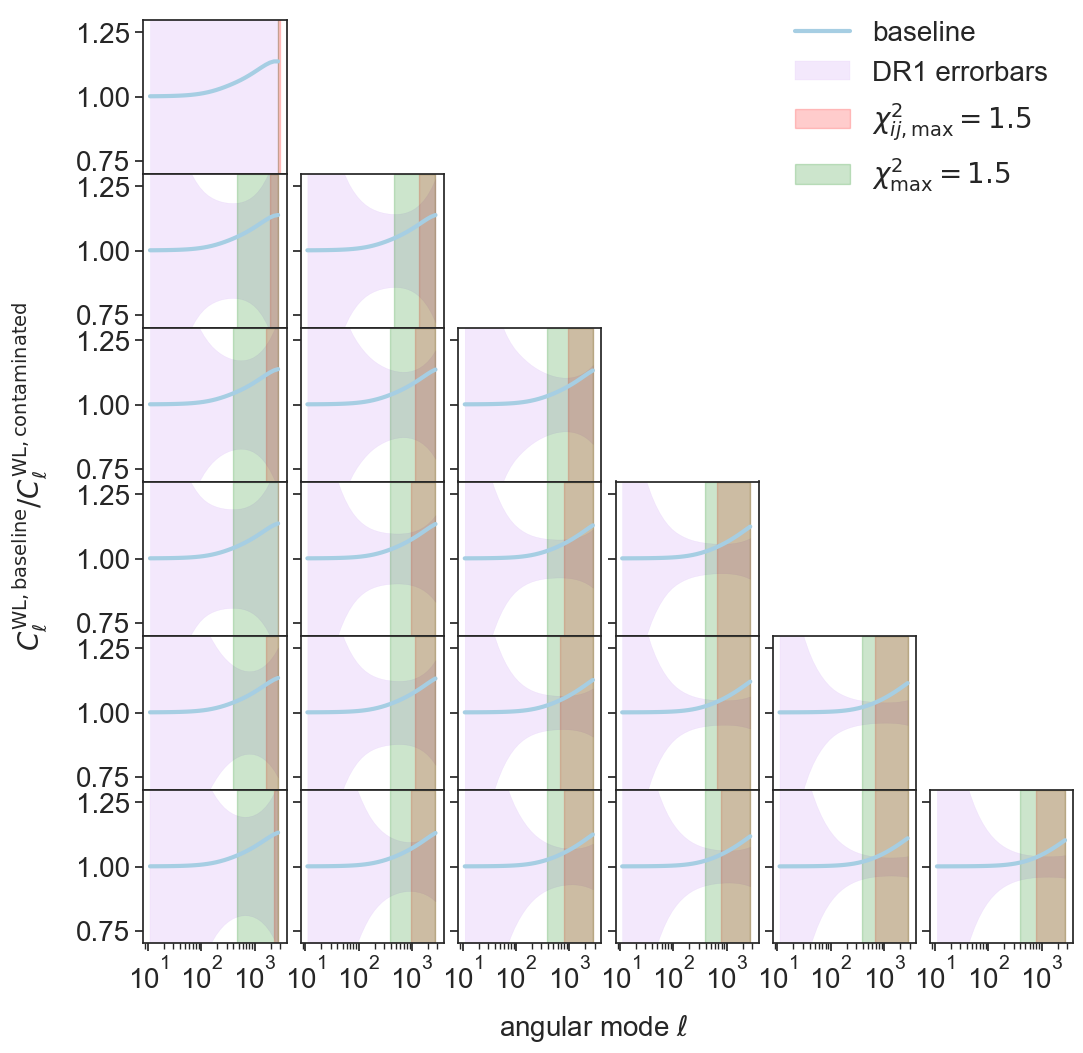

In [27]:
fig, ax = plt.subplots(n_she_bins, n_she_bins, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(n_she_bins):
    for j in range(n_she_bins):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            y = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            ax[i,j].semilogx(ell_theory,  y, color='C0')


            diff = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            mask = ell_theory<ell_max_start
            chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
            n = 1
            chi2_new = chi2
            mask_new = ell_theory < ell_max_start
            if chi2>chi2_max_ij:
                while chi2_new>chi2_max_ij:
                    mask_new = ell_theory < (ell_max_start - n)
                    chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                    n +=1
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )


            ax[i, j].set_ylim(0.7, 1.3)

            ax[i, j].axvspan(xmin=ell_max_start - n, xmax=ell_theory[-1], color='red', alpha=0.2)
            ax[i, j].axvspan(xmin=ell_max_per_bin[f"bin {j+1}{i+1}"], xmax=ell_theory[-1], color='green', alpha=0.2)    
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL, baseline}_{\ell}/C^{\rm WL, contaminated}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(
    [
        'baseline',
        'DR1 errorbars',
        f'$\\chi^2_{{ij, \\rm max}}={chi2_max_ij}$',
        f'$\\chi^2_{{\\rm max}}={chi2_max}$'
    ],
    loc='upper right',
    ncol=1,
    bbox_to_anchor=(0.9, 0.9),
    bbox_transform=fig.transFigure,
    fontsize=20,
    frameon=False,
    title_fontsize=20
)

# Next we asses the shifts in $\sigma$

Run chains with the initial scale-cuts from above in 2 set-ups:
1. baseline model on baseline fiducial data
2. baseline model on contaminated data

We also compute FoM and FoB. The confidence intervals for FoB are calculated by direct integration of a two-dimensional Gaussian over an ellipse between $\pm$ FoB and equating the integral to the 68th and 95th percentile thresholds, which in a two parameter case results in FoB equal to 1.52 and 2.49, respectively.

In [29]:
import getdist.plots
import yaml
# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("../../scripts/plotting/params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

In [30]:
chain_baseline = np.load('../../scripts/sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_lcdm_baryons_chi2ijcuts_contaminated.npz', allow_pickle=True)
#chain, derived, weights, logl, param_names,derived_names,logz,chain_time, chain_time_hms, fiducial
#fiducials  = chain_baseline['fiducial'].flat[0]


fiducials  = fiducial_cosmology
fiducials['h'] = fiducials['H0']/100.
fiducials['logAs'] = np.log(1e10*fiducials['As'])
fiducials['omch2'] = fiducials['Omega_cdm0']*fiducials['h']*fiducials['h']
fiducials['ombh2'] = fiducials['Omega_b0']*fiducials['h']*fiducials['h']
fiducials['Omega_m'] = (fiducials['omch2']+fiducials['ombh2']+fiducials['mnu']/93.14)/fiducials['h']**2
fiducials['S8'] = fiducials['sigma8_0']*np.sqrt(fiducials['Omega_m']/0.3)

In [31]:
chain_baseline['param_names']

array(['Omega_cdm0', 'Omega_b0', 'H0', 'logAs', 'ns', 'AIA', 'EtaIA',
       'b1_photo_poly0', 'b1_photo_poly1', 'b1_photo_poly2',
       'b1_photo_poly3', 'multiplicative_bias_1', 'multiplicative_bias_2',
       'multiplicative_bias_3', 'multiplicative_bias_4',
       'multiplicative_bias_5', 'multiplicative_bias_6', 'dz_pos_1',
       'dz_pos_2', 'dz_pos_3', 'dz_pos_4', 'dz_pos_5', 'dz_pos_6',
       'dz_shear_1', 'dz_shear_2', 'dz_shear_3', 'dz_shear_4',
       'dz_shear_5', 'dz_shear_6'], dtype='<U21')

In [32]:
file_paths = [
#'../../scripts/sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_lcdm_baryons_chi2ijcuts_baseline.npz',
#'../../scripts/sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_lcdm_baryons_chi2ijcuts_contaminated.npz'

'../../scripts/sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_lcdm_baryons_chi2totcuts_baseline.npz',
'../../scripts/sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_lcdm_baryons_chi2totcuts_contaminated.npz'
]

In [33]:
n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain_npz = np.load(file_path, allow_pickle=True)
        
    
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = np.vstack([chain_npz['chain'].flat[0][par] for par in chain_npz['param_names']]).T
    chains_info[i]['chain'] = np.hstack((chains_info[i]['chain'], chain_npz['derived'].flat[0]['sigma8_0'][:, np.newaxis]))
    print(chains_info[i]['chain'].shape)
    chains_info[i]['weights'] = chain_npz['weights']
    chains_info[i]['logl'] = chain_npz['logl']
    chains_info[i]['pars'] = np.hstack((chain_npz['param_names'], chain_baseline['derived_names']))
    chains_info[i]['fiducial'] = chain_npz['fiducial'].flat[0]


(18724, 30)
(19344, 30)


In [34]:
samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    samples.append(
        getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = chains_info[i]['chain'],
            # Parameter names
            names = [i for i in chains_info[i]['pars']],
            # Sample weights (exponential of log-likelihood)
            weights=np.exp(chains_info[i]['weights']),
            # LaTeX labels for parameters (from params_dic)
            labels = [params_dic[p] for p in chains_info[i]['pars']],
            # Smoothing settings for 1D and 2D distributions
            #settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
            # Parameter ranges for plotting
            #ranges = Ranges
        ) 
    )
    mnu = chains_info[i]['fiducial']['mnu']
    # Get parameter object (unused but kept for compatibility)
    p = samples[i].getParams() 
    samples[i].addDerived(p.H0/100., 'h','h')
    p = samples[i].getParams() 
    samples[i].addDerived((p.Omega_cdm0+p.Omega_b0+mnu/93.14/p.h**2), 'Omega_m','\Omega_{\\rm m}')
    p = samples[i].getParams() 
    samples[i].addDerived(p.sigma8_0*np.sqrt(p.Omega_m/0.3), 'S8', 'S_8')

Removed no burn in
Removed no burn in


<>:25: SyntaxWarning: invalid escape sequence '\O'
<>:25: SyntaxWarning: invalid escape sequence '\O'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_46580/1585387735.py:25: SyntaxWarning: invalid escape sequence '\O'
  samples[i].addDerived((p.Omega_cdm0+p.Omega_b0+mnu/93.14/p.h**2), 'Omega_m','\Omega_{\\rm m}')


<>:44: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\c'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_46580/3858562697.py:44: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2_{\\rm tot}<1.5$'


Text(0.98, 1.2, '$\\chi^2_{\\rm tot}<1.5$')

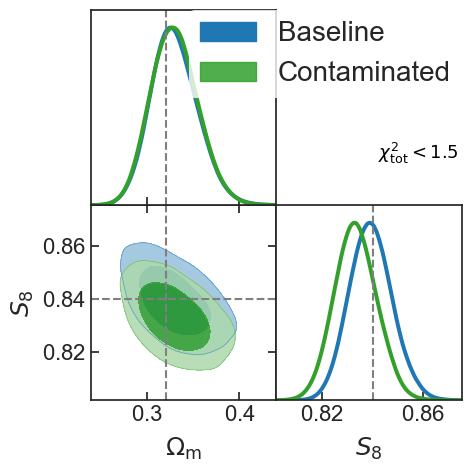

In [35]:
# Plot with GetDist 
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=2.5)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame
ModelPars = ['Omega_m', 'S8']
legend_labels = ['Baseline', 'Contaminated']
colors = ['C1', 'C3']
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
    ]
)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=1.5, color='tab:gray', linestyle='--')
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=1.5, color='tab:gray', linestyle='--')
# Annotate lower right with FoM and FoB information for baseline and contamination
annot_text = (
    '$\chi^2_{\\rm tot}<1.5$'
)

# Place in lower right, slightly in from edges
ax.annotate(annot_text,
            xy=(0.98, 1.2), xycoords='axes fraction',
            fontsize=13, color='black', ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
            linespacing=1.5)

baseline [0.32972882 0.83916358]
contaminated [0.32984819 0.83318973]
fiducial [0.32084164 0.84010219]
FoM_baseline     = 5342.3159
FoM_contaminated = 5241.8097
FoB_baseline     = 0.3589
FoB_contaminated = 0.8203
baseline:  0.07825206232496575
contaminated:  0.3661191671738123
contaminated -> baseline:  0.1867623353230015


<>:126: SyntaxWarning: invalid escape sequence '\c'
<>:126: SyntaxWarning: invalid escape sequence '\c'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_46580/4110217438.py:126: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2_{\\rm tot}<1.5$\n'


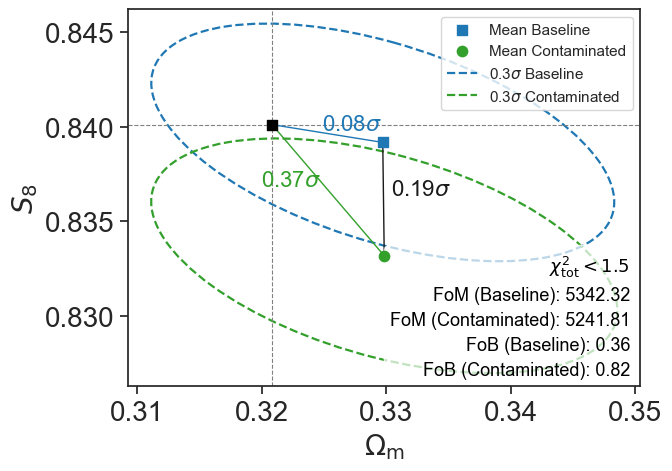

In [36]:
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy.stats import chi2
from scipy.special import erf, erfinv

fid_Omega_m = float(fiducials['Omega_m'])
fid_S8      = float(fiducials['S8'])
fid_vec     = np.array([fid_Omega_m, fid_S8])

means, covs = [], []
for s in samples:
    p  = s.getParams()
    Om = np.asarray(p.Omega_m)
    S8 = np.asarray(p.S8)
    w  = np.asarray(s.weights)
    means.append(np.array([np.average(Om, weights=w),
                           np.average(S8, weights=w)]))
    covs.append(np.cov(np.vstack([Om, S8]), aweights=w))

print('baseline', means[0])
print('contaminated', means[1])
print('fiducial', fid_vec)
# --- Figure of Merit and Figure of Bias ------------------------------------
FoM_baseline     = 1. / np.sqrt(abs(np.linalg.det(covs[0])))
FoM_contaminated = 1. / np.sqrt(abs(np.linalg.det(covs[1])))
print(f'FoM_baseline     = {FoM_baseline:.4f}')
print(f'FoM_contaminated = {FoM_contaminated:.4f}')

diff_vec         = means[0] - fid_vec
FoB_baseline     = np.sqrt(diff_vec @ np.linalg.inv(covs[0]) @ diff_vec)
diff_vec         = means[1] - fid_vec
FoB_contaminated = np.sqrt(diff_vec @ np.linalg.inv(covs[1]) @ diff_vec)
print(f'FoB_baseline     = {FoB_baseline:.4f}')
print(f'FoB_contaminated = {FoB_contaminated:.4f}')
# --- Tension convention ----------------------
# `n_sigma` is the desired contour level expressed as a 1-D-equivalent sigma:
#     n_sigma = 1    -> 68.27% containment ellipse  (matches GetDist 1-sigma)
#     n_sigma = 0.3  -> ~23.6% containment ellipse
#     n_sigma = 2    -> 95.45% containment ellipse  (matches GetDist 2-sigma)
# The same convention is used for the printed shift labels, so a label
# "0.34 sigma" means "as unlikely as a 0.34 sigma excursion of a 1-D Gaussian".
n_sigma = 0.3

# 2-D containment probability that corresponds to n_sigma in 1-D.
level       = erf(n_sigma / np.sqrt(2))                # e.g. 0.6827 for 1sigma
# Mahalanobis radius of the ellipse for that containment level.
n_sigma_eff = np.sqrt(chi2.ppf(level, df=2))           # e.g. ~1.515 for 1sigma

def shift_sigma(a, b, cov):
    """Shift between a and b expressed as a 1-D-equivalent sigma (PTE).

        d_M^2 = (a - b)^T C^{-1} (a - b)
        p     = exp(-d_M^2 / 2)               # 2-D Gaussian tail probability
        N     = sqrt(2) * erfinv(1 - p)       # equivalent 1-D Gaussian sigma
    """
    d   = a - b
    dM2 = float(d @ np.linalg.inv(cov) @ d)
    p   = np.exp(-dM2 / 2)
    return float(np.sqrt(2) * erfinv(1.0 - p))

fig, ax = plt.subplots(figsize=(7, 5))

colors       = ['C1', 'C3']
markers      = ['s', 'o']
chain_labels = ['Baseline', 'Contaminated']

ax.axvline(fid_Omega_m, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(fid_S8,      color='gray', linestyle='--', linewidth=0.8)
ax.scatter([fid_Omega_m], [fid_S8],
           marker='s', color='black', s=45, zorder=6)

for mu, cov, col in zip(means, covs, colors):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order            = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle  = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width  = 2 * n_sigma_eff * np.sqrt(eigvals[0])
    height = 2 * n_sigma_eff * np.sqrt(eigvals[1])
    ax.add_patch(Ellipse(xy=mu, width=width, height=height, angle=angle,
                         edgecolor=col, facecolor='none',
                         linestyle='--', linewidth=1.6))


# Mahalanobis distance for baseline
ax.plot([fid_vec[0], means[0][0]], [fid_vec[1], means[0][1]], color='C1', linewidth=1.)
s = shift_sigma(fid_vec, means[0], covs[0])
print('baseline: ', s)
ax.text(0.5 * (fid_vec[0] + means[0][0])+0.002, 0.5 * (fid_vec[1] + means[0][1]),
             f'{s:.2f}' + r'$\sigma$',
             fontsize=16, ha='center', va='bottom', color='C1')
# Mahalanobis distance for contamination
ax.plot([fid_vec[0], means[1][0]], [fid_vec[1], means[1][1]], color='C3', linewidth=1.)
s = shift_sigma(fid_vec, means[1], covs[1])
print('contaminated: ', s)
ax.text(0.5 * (fid_vec[0] + means[1][0])-0.003, 0.5 * (fid_vec[1] + means[1][1]),
             f'{s:.2f}' + r'$\sigma$',
             fontsize=16, ha='center', va='bottom', color='C3')     
# Mahalanobis distance for contamination -> baseline
ax.plot([means[1][0], means[0][0]], [means[1][1], means[0][1]], color='k', linewidth=1.)
s = shift_sigma(means[1], means[0], covs[1] + covs[0])
print('contaminated -> baseline: ', s)
ax.text(0.5 * (means[1][0] + means[0][0])+0.003, 0.5 * (means[1][1] + means[0][1]),
             f'{s:.2f}' + r'$\sigma$',
             fontsize=16, ha='center', va='bottom', color='k')     

mean_handles = []
for mu, col, mk, lbl in zip(means, colors, markers, chain_labels):
    h = ax.scatter([mu[0]], [mu[1]], marker=mk, color=col,
                   s=55, zorder=6, label=f'Mean {lbl}')
    mean_handles.append(h)

contour_handles = [
    Line2D([0], [0], color=col, linestyle='--', linewidth=1.6,
           label=f'{n_sigma:.1f}' + r'$\sigma$ ' + lbl)
    for col, lbl in zip(colors, chain_labels)
]
ax.legend(handles=mean_handles + contour_handles,
          loc='upper right', frameon=True, fontsize=11)


ax.set_xlabel(r'$\Omega_{\rm m}$', fontsize=20)
ax.set_ylabel(r'$S_8$',      fontsize=20)

# Annotate lower right with FoM and FoB information for baseline and contamination
annot_text = (
    '$\chi^2_{\\rm tot}<1.5$\n'
    f'FoM (Baseline): {FoM_baseline:.2f}\n'
    f'FoM (Contaminated): {FoM_contaminated:.2f}\n'
    f'FoB (Baseline): {FoB_baseline:.2f}\n'
    f'FoB (Contaminated): {FoB_contaminated:.2f}'
)

# Place in lower right, slightly in from edges
ax.annotate(annot_text,
            xy=(0.98, 0.02), xycoords='axes fraction',
            fontsize=13, color='black', ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
            linespacing=1.5)

plt.tight_layout()
plt.show()


<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_46580/3233978020.py:43: SyntaxWarning: invalid escape sequence '\c'
  loc='upper right', frameon=True, fontsize=11, title='$\chi^2_{\\rm tot}<1.5$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_46580/3233978020.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


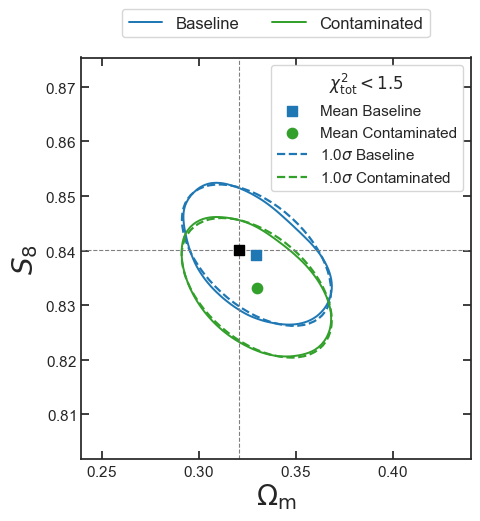

In [37]:
# Sanity check: compare Mahalanobis distance with GetDist's 1-sigma contour

from getdist import plots
g = plots.get_subplot_plotter(subplot_size=5)
g.settings.linewidth=1    
g.settings.num_plot_contours = 1
g.rectangle_plot("Omega_m", "S8", roots=samples, legend_labels=["Baseline", "Contaminated"], colors=["C1", "C3"])
ax = g.subplots[0, 0]

ax.axvline(fid_Omega_m, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(fid_S8,      color='gray', linestyle='--', linewidth=0.8)
ax.scatter([fid_Omega_m], [fid_S8],
           marker='s', color='black', s=45, zorder=6)

n_sigma = 1.
level       = erf(n_sigma / np.sqrt(2))               
n_sigma_eff = np.sqrt(chi2.ppf(level, df=2))     
for mu, cov, col in zip(means, covs, colors):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order            = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle  = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width  = 2 * n_sigma_eff * np.sqrt(eigvals[0])
    height = 2 * n_sigma_eff * np.sqrt(eigvals[1])
    ax.add_patch(Ellipse(xy=mu, width=width, height=height, angle=angle,
                         edgecolor=col, facecolor='none',
                         linestyle='--', linewidth=1.6))



mean_handles = []
for mu, col, mk, lbl in zip(means, colors, markers, chain_labels):
    h = ax.scatter([mu[0]], [mu[1]], marker=mk, color=col,
                   s=55, zorder=6, label=f'Mean {lbl}')
    mean_handles.append(h)

contour_handles = [
    Line2D([0], [0], color=col, linestyle='--', linewidth=1.6,
           label=f'{n_sigma:.1f}' + r'$\sigma$ ' + lbl)
    for col, lbl in zip(colors, chain_labels)
]
ax.legend(handles=mean_handles + contour_handles,
          loc='upper right', frameon=True, fontsize=11, title='$\chi^2_{\\rm tot}<1.5$')


ax.set_xlabel(r'$\Omega_{\rm m}$', fontsize=20)
ax.set_ylabel(r'$S_8$',      fontsize=20)

plt.tight_layout()
plt.show()